# Pass 2 Universes

Pass 2 runs three universes: main (reused from Pass 1), control (new, no crypto filter), and KR KOSPI large-cap (new, $50M ADV). Main and control are the central methodological contrast for the circularity test. Large-cap was anticipated as a risk (brief risk #3) and materialized.

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

BASE = '/Users/idrees/Desktop/Claude/projects/crypto_overnight_em_equity_p2/output'

main = pd.read_csv(f'{BASE}/universe_log.csv', parse_dates=['date'])
ctrl = pd.read_csv(f'{BASE}/control_universe_log.csv', parse_dates=['date'])
kospi = pd.read_csv(f'{BASE}/kospi_largecap_universe_log.csv', parse_dates=['date'])

print('main shape:', main.shape, '| cols:', main.columns.tolist())
print('ctrl shape:', ctrl.shape, '| cols:', ctrl.columns.tolist())
print('kospi shape:', kospi.shape, '| cols:', kospi.columns.tolist())

main shape: (4561, 6) | cols: ['date', 'market', 'ticker', 'btc_corr', 'adv_usd', 'rank']
ctrl shape: (5238, 5) | cols: ['date', 'market', 'ticker', 'adv_usd', 'rank']
kospi shape: (130, 6) | cols: ['date', 'ticker', 'adv_usd', 'btc_corr_60d', 'rank', 'flat_month_flag']


## Universe Size Over Time

The main universe holds crypto-exposed HK and KR names (filtered by BTC correlation rank). The control universe holds size/liquidity-matched non-crypto-exposed names from the same markets. The large-cap universe targets KOSPI names meeting a $50M ADV threshold.

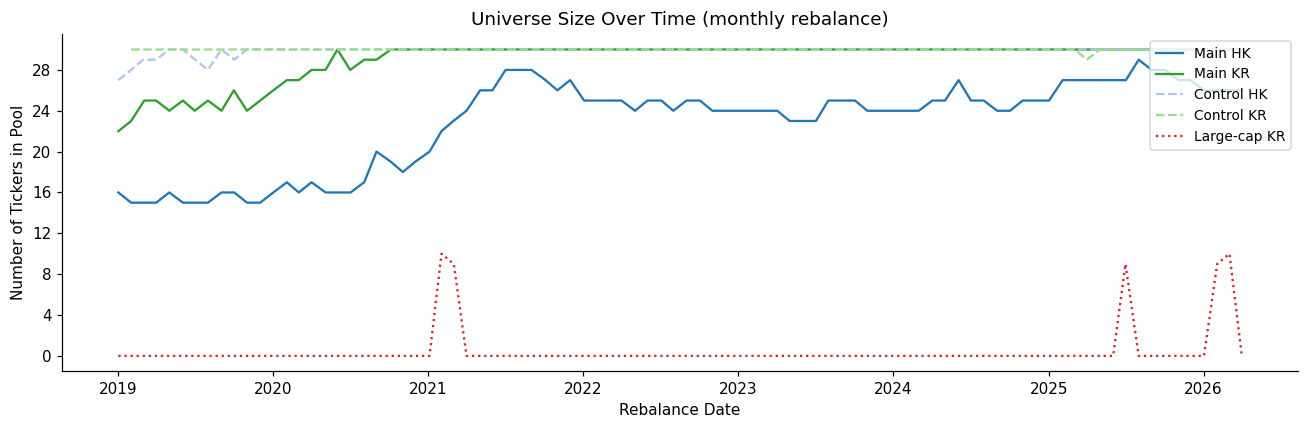

In [2]:
# Count tickers per rebalance date per market
main_hk = main[main['market']=='HK'].groupby('date')['ticker'].count().rename('Main HK')
main_kr = main[main['market']=='KR'].groupby('date')['ticker'].count().rename('Main KR')
ctrl_hk = ctrl[ctrl['market']=='HK'].groupby('date')['ticker'].count().rename('Control HK')
ctrl_kr = ctrl[ctrl['market']=='KR'].groupby('date')['ticker'].count().rename('Control KR')

# Large-cap: count non-NaN tickers per date
lc_size = kospi.groupby('date')['ticker'].count().rename('Large-cap KR')

fig, ax = plt.subplots(figsize=(12, 4))
for series, ls, color in [
    (main_hk,  '-',  '#1f77b4'),
    (main_kr,  '-',  '#2ca02c'),
    (ctrl_hk,  '--', '#aec7e8'),
    (ctrl_kr,  '--', '#98df8a'),
    (lc_size,  ':',  '#d62728'),
]:
    ax.plot(series.index, series.values, linestyle=ls, color=color, label=series.name, linewidth=1.5)

ax.set_title('Universe Size Over Time (monthly rebalance)', fontsize=12)
ax.set_xlabel('Rebalance Date')
ax.set_ylabel('Number of Tickers in Pool')
ax.legend(loc='upper right', fontsize=9)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

Main and control universes are stable at roughly 25-30 names each per market throughout the sample. The large-cap KR series is nearly always zero (flat months), confirming the pool exhaustion problem.

## Ticker Overlap Between Main and Control

The control universe was constructed to exclude crypto-exposed names. Zero overlap with the main universe is the expected and desired outcome. Any overlap would indicate the control is contaminated.

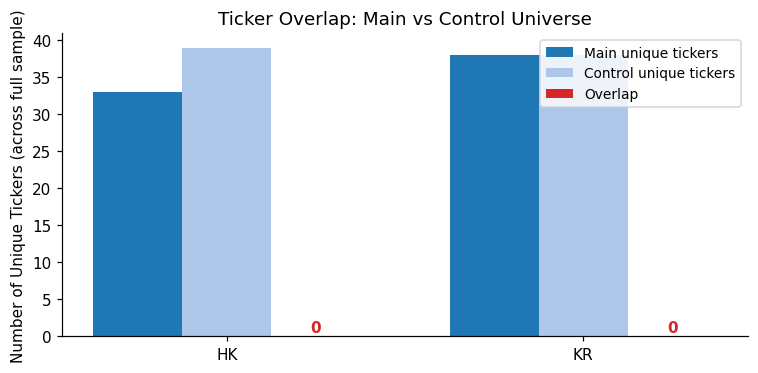

Market  Main unique  Control unique  Overlap
    HK           33              39        0
    KR           38              38        0


In [3]:
overlap_data = []
for mkt in ['HK', 'KR']:
    main_tickers = set(main[main['market']==mkt]['ticker'].unique())
    ctrl_tickers = set(ctrl[ctrl['market']==mkt]['ticker'].unique())
    overlap = len(main_tickers & ctrl_tickers)
    overlap_data.append({'Market': mkt, 'Main unique': len(main_tickers),
                         'Control unique': len(ctrl_tickers), 'Overlap': overlap})

df_overlap = pd.DataFrame(overlap_data)

fig, ax = plt.subplots(figsize=(7, 3.5))
x = np.arange(len(df_overlap))
w = 0.25
bars_main = ax.bar(x - w, df_overlap['Main unique'], width=w, label='Main unique tickers', color='#1f77b4')
bars_ctrl = ax.bar(x, df_overlap['Control unique'], width=w, label='Control unique tickers', color='#aec7e8')
bars_ol   = ax.bar(x + w, df_overlap['Overlap'], width=w, label='Overlap', color='#d62728')

ax.set_xticks(x)
ax.set_xticklabels(df_overlap['Market'])
ax.set_title('Ticker Overlap: Main vs Control Universe', fontsize=12)
ax.set_ylabel('Number of Unique Tickers (across full sample)')
ax.legend(fontsize=9)

for bar in bars_ol:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.2, str(int(h)),
            ha='center', va='bottom', fontsize=10, color='#d62728', fontweight='bold')

plt.tight_layout()
plt.show()

print(df_overlap.to_string(index=False))

Zero overlap in both markets. Main and control universes are fully disjoint, which is required for a valid circularity test. The control group is uncontaminated.

## ADV Distributions at Last Rebalance Date

The main universe applies a $500K ADV threshold. The large-cap universe applies a $50M ADV threshold. This chart shows the spread of ADV values across the three pools at the last rebalance date (2026-04-01). The large-cap date used is 2021-02-01, the first non-flat rebalance month, since the last date is a flat month.

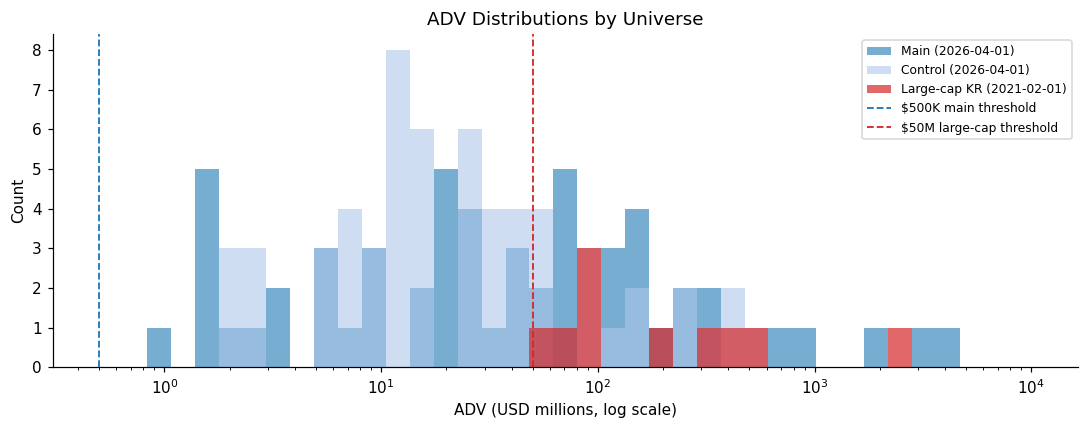

In [4]:
rep_date_main = main['date'].max()
rep_date_kospi = pd.Timestamp('2021-02-01')  # first non-flat month with a full pool

adv_main = main[main['date']==rep_date_main]['adv_usd'].dropna() / 1e6
adv_ctrl = ctrl[ctrl['date']==rep_date_main]['adv_usd'].dropna() / 1e6
adv_lc   = kospi[(kospi['date']==rep_date_kospi) & (~kospi['flat_month_flag'])]['adv_usd'].dropna() / 1e6

fig, ax = plt.subplots(figsize=(10, 4))

bins = np.logspace(np.log10(0.5), np.log10(10000), 40)
ax.hist(adv_main, bins=bins, alpha=0.6, label=f'Main ({rep_date_main.date()})', color='#1f77b4')
ax.hist(adv_ctrl, bins=bins, alpha=0.6, label=f'Control ({rep_date_main.date()})', color='#aec7e8')
ax.hist(adv_lc, bins=bins, alpha=0.7, label=f'Large-cap KR ({rep_date_kospi.date()})', color='#d62728')

ax.axvline(0.5, color='#1f77b4', linestyle='--', linewidth=1.2, label='$500K main threshold')
ax.axvline(50,  color='#d62728', linestyle='--', linewidth=1.2, label='$50M large-cap threshold')

ax.set_xscale('log')
ax.set_xlabel('ADV (USD millions, log scale)')
ax.set_ylabel('Count')
ax.set_title('ADV Distributions by Universe', fontsize=12)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Main universe names range from near the $500K floor up to several billion. The large-cap pool sits well above the $50M threshold when it exists, but those months are rare. The $50M requirement eliminates nearly all KOSPI months from consideration.

## BTC Correlation Distributions

The main universe selects the top-24/30 names by 60-day BTC correlation. The control universe applies no BTC correlation filter. The `universe_log.csv` contains `btc_corr` values for the main universe. The `control_universe_log.csv` does not contain BTC correlation values (no filter was applied), so the control distribution is not shown.

In [5]:
has_main_corr = 'btc_corr' in main.columns
has_ctrl_corr = 'btc_corr' in ctrl.columns
has_lc_corr   = 'btc_corr_60d' in kospi.columns

print(f'BTC correlation column present - main: {has_main_corr}, control: {has_ctrl_corr}, large-cap: {has_lc_corr}')

if not has_ctrl_corr:
    print('Note: control_universe_log.csv has no BTC correlation column; no filter was applied at construction.')

BTC correlation column present - main: True, control: False, large-cap: True
Note: control_universe_log.csv has no BTC correlation column; no filter was applied at construction.


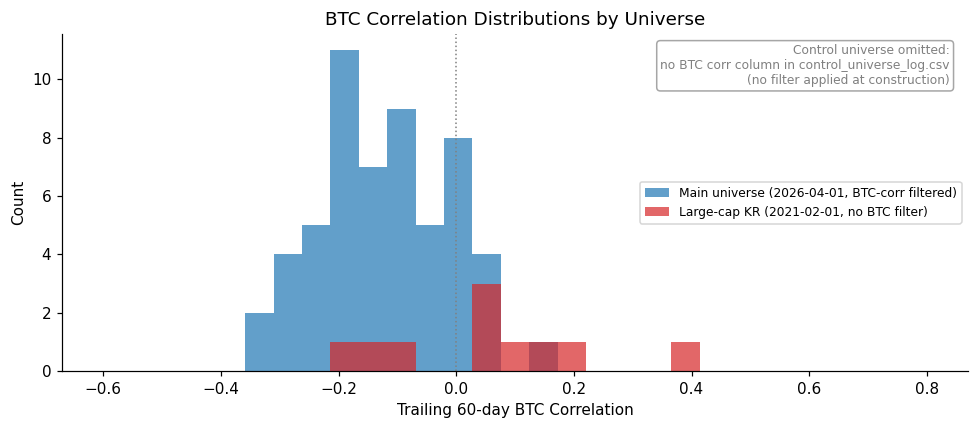

In [6]:
# Show distribution at last main rebalance date for main, and 2021-02-01 for large-cap
if has_main_corr:
    corr_main = main[main['date']==rep_date_main]['btc_corr'].dropna()
else:
    corr_main = pd.Series(dtype=float)

if has_lc_corr:
    corr_lc = kospi[(kospi['date']==rep_date_kospi) & (~kospi['flat_month_flag'])]['btc_corr_60d'].dropna()
else:
    corr_lc = pd.Series(dtype=float)

if corr_main.empty and corr_lc.empty:
    print('No BTC correlation data available in any universe file. Skipping chart.')
else:
    fig, ax = plt.subplots(figsize=(9, 4))
    bins = np.linspace(-0.6, 0.8, 30)
    if not corr_main.empty:
        ax.hist(corr_main, bins=bins, alpha=0.7,
                label=f'Main universe ({rep_date_main.date()}, BTC-corr filtered)',
                color='#1f77b4')
    if not corr_lc.empty:
        ax.hist(corr_lc, bins=bins, alpha=0.7,
                label=f'Large-cap KR ({rep_date_kospi.date()}, no BTC filter)',
                color='#d62728')
    ax.axvline(0, color='grey', linestyle=':', linewidth=1)
    ax.set_xlabel('Trailing 60-day BTC Correlation')
    ax.set_ylabel('Count')
    ax.set_title('BTC Correlation Distributions by Universe', fontsize=12)
    ax.text(0.98, 0.97,
            'Control universe omitted:\nno BTC corr column in control_universe_log.csv\n(no filter applied at construction)',
            transform=ax.transAxes, ha='right', va='top', fontsize=8, color='grey',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='grey', alpha=0.7))
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

Main universe names are positively correlated with BTC (by construction, top-24/30 filter). Large-cap KR names from the non-flat months span a wider range, including negative correlations, consistent with no BTC filter being applied. Control universe BTC correlations are not available in the log file because no correlation filter was used during construction.

## KOSPI Large-cap Pool Composition

**FLAGGED INCONCLUSIVE** (brief risk #3). The large-cap universe requires at least 9 names per rebalance month. The $50M ADV threshold eliminates nearly all months. The flat-month rate is 94% (83 of 88 rebalance months). Only 5 months have a pool meeting the minimum requirement.

In [7]:
# Build per-date pool size and flat flag
# Flat months have 0 or NaN tickers; non-flat have actual data
lc_pool = kospi.groupby('date').agg(
    pool_size=('ticker', 'count'),
    is_flat=('flat_month_flag', 'all')
).reset_index()

# Pool size is 0 for flat months (all tickers are NaN)
# Verify
flat_months = lc_pool[lc_pool['is_flat']]
nonflat_months = lc_pool[~lc_pool['is_flat']]
flat_rate = len(flat_months) / len(lc_pool)

MIN_POOL = 9

print(f'Total rebalance months: {len(lc_pool)}')
print(f'Flat months (pool = 0): {len(flat_months)}')
print(f'Non-flat months: {len(nonflat_months)}')
print(f'Flat-month rate: {flat_rate:.1%}')
print()
print('Non-flat months pool sizes:')
print(nonflat_months[['date','pool_size']].to_string(index=False))

Total rebalance months: 88
Flat months (pool = 0): 83
Non-flat months: 5
Flat-month rate: 94.3%

Non-flat months pool sizes:
      date  pool_size
2021-02-01         10
2021-03-02          9
2025-07-01          9
2026-02-02          9
2026-03-03         10


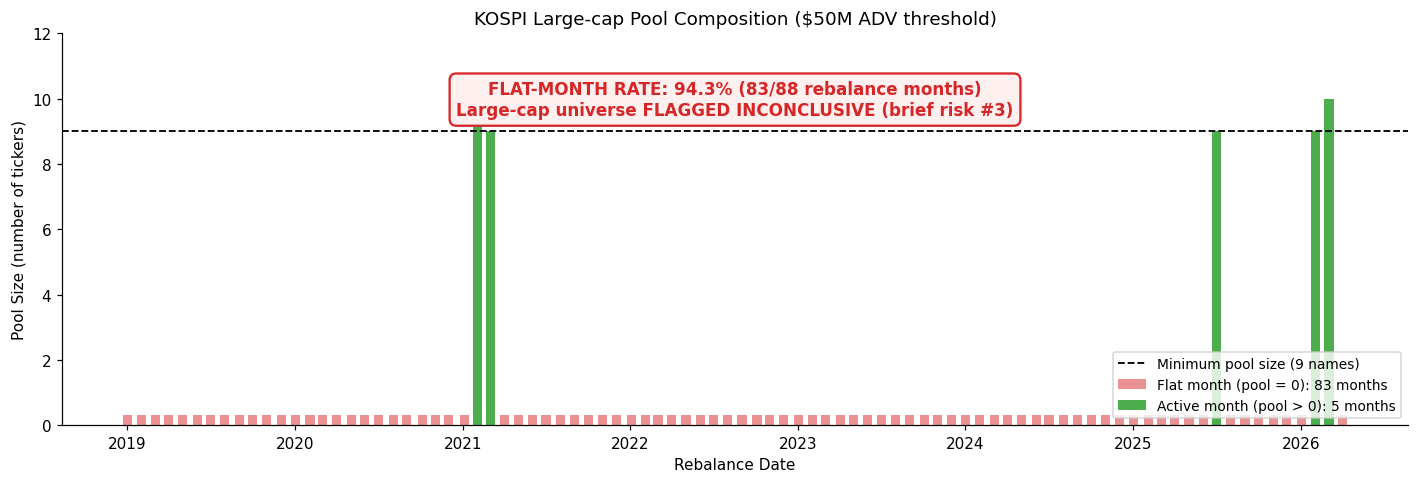

In [8]:
fig, ax = plt.subplots(figsize=(13, 4.5))

# Flat months as background bar (height 0, shown as thin red ticks at zero)
ax.bar(lc_pool[lc_pool['is_flat']]['date'],
       [0.3] * len(flat_months),
       color='#d62728', alpha=0.5, width=20,
       label=f'Flat month (pool = 0): {len(flat_months)} months')

# Non-flat months as solid bars
ax.bar(lc_pool[~lc_pool['is_flat']]['date'],
       lc_pool[~lc_pool['is_flat']]['pool_size'],
       color='#2ca02c', alpha=0.85, width=20,
       label=f'Active month (pool > 0): {len(nonflat_months)} months')

# Minimum pool size line
ax.axhline(MIN_POOL, color='black', linestyle='--', linewidth=1.2,
           label=f'Minimum pool size ({MIN_POOL} names)')

# Annotate flat-month rate prominently
ax.text(0.5, 0.88,
        f'FLAT-MONTH RATE: {flat_rate:.1%} ({len(flat_months)}/{len(lc_pool)} rebalance months)\n'
        f'Large-cap universe FLAGGED INCONCLUSIVE (brief risk #3)',
        transform=ax.transAxes, ha='center', va='top',
        fontsize=11, color='#d62728', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff0f0', edgecolor='#d62728', linewidth=1.5))

ax.set_xlabel('Rebalance Date')
ax.set_ylabel('Pool Size (number of tickers)')
ax.set_title('KOSPI Large-cap Pool Composition ($50M ADV threshold)', fontsize=12)
ax.legend(fontsize=9, loc='lower right')
ax.set_ylim(0, max(lc_pool['pool_size'].max() + 2, MIN_POOL + 3))
plt.tight_layout()
plt.show()

The large-cap pool is viable in only 5 of 88 rebalance months (5.7%), all clustered around early 2021 and 2025-2026. The $50M ADV bar is too high for the KOSPI universe given the sample. This materialized exactly as brief risk #3 anticipated.

## Summary

- **Main universe** (crypto-filtered HK and KR): stable pool of 25-30 names per market, monthly rebalance, zero overlap with control. BTC correlation filter is active (top-24/30 by trailing 60-day correlation).
- **Control universe** (no crypto filter): matched on size and liquidity, same markets. Zero ticker overlap with main in both HK and KR across the full sample, confirming the control is uncontaminated.
- **KOSPI large-cap universe**: FLAGGED INCONCLUSIVE per brief risk #3. A 94% flat-month rate under the $50M ADV threshold leaves only 5 viable rebalance months across the full 2019-2026 sample. A backtest on this universe would not be statistically meaningful.
- **Downstream**: the backtest (Pass 2) ran main and control configurations only. All large-cap configurations were skipped. This decision is consistent with the pre-registered risk flag in the brief.